In [44]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time 

import pyreadr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn import set_config

# Configuración de visualización
set_config(display='diagram')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

SEED = 123
np.random.seed(SEED)

In [45]:
# Ajustar la ruta al archivo según corresponda
RUTA_DATOS = 'listings.RData'

resultado = pyreadr.read_r(RUTA_DATOS)
df = resultado['listings']

print(f"Dimensiones originales: {df.shape}")
print(f"Cantidad de variables: {df.shape[1]}")
df.head()

Dimensiones originales: (171748, 80)
Cantidad de variables: 80


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [46]:
# Ver los tipos de variables
print("Distribución de tipos de datos:")
print(df.dtypes.value_counts())
# Distribución por ciudad
print("\nListings por ciudad:")
print(df['city'].value_counts())

Distribución de tipos de datos:
object     47
int32      18
float64    15
Name: count, dtype: int64

Listings por ciudad:
city
Los Angeles, California      45585
New York, New York           36261
Hawaii                       33457
San Diego, California        13162
Austin, Texas                10533
Chicago, Illinois             8660
San Francisco, California     7535
Washington, D.C.              6374
Rhode Island                  5762
Boston, Massachusetts         4419
Name: count, dtype: int64


In [47]:
df['price_num'] = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

print("Estadísticas de price_num:")
print(df['price_num'].describe())
print(f"\nNulos en price: {df['price_num'].isna().sum()} "
      f"({df['price_num'].isna().mean()*100:.1f}%)")

Estadísticas de price_num:
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price_num, dtype: float64

Nulos en price: 95502 (55.6%)


In [48]:
# Nulos de precio por ciudad
print("Porcentaje de precios nulos por ciudad:")
nulos_ciudad = df.groupby('city')['price_num'].apply(
    lambda x: x.isna().mean()*100
).sort_values(ascending=False)
print(nulos_ciudad.round(2))

Porcentaje de precios nulos por ciudad:
city
Los Angeles, California      100.00
New York, New York           100.00
San Francisco, California    100.00
Washington, D.C.              23.25
Boston, Massachusetts         20.66
San Diego, California         13.53
Rhode Island                  13.35
Chicago, Illinois              9.64
Hawaii                         0.97
Austin, Texas                  0.15
Name: price_num, dtype: float64


In [49]:
# Filtrar registros con precio válido
df = df[df['price_num'].notna()].copy()
print(f"Dimensiones tras filtrar nulos de precio: {df.shape}")

Dimensiones tras filtrar nulos de precio: (76246, 81)


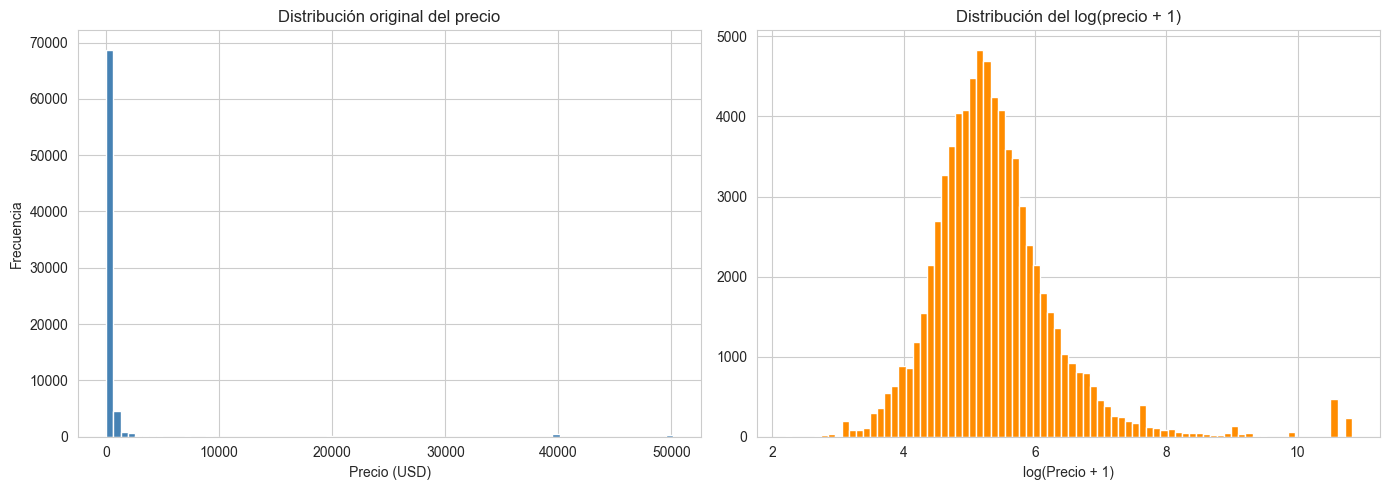

Skewness original: 9.87


In [50]:
## Distribución de precios por ciudad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price_num'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución original del precio')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['price_num']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución del log(precio + 1)')
axes[1].set_xlabel('log(Precio + 1)')
plt.tight_layout()
plt.show()

print(f"Skewness original: {df['price_num'].skew():.2f}")

In [51]:
p99 = np.percentile(df['price_num'], 99)
print(f"P99 del precio: ${p99:.2f}")
df = df[df['price_num'] <= p99].copy()
print(f"Dimensiones después de filtrar outliers: {df.shape}")

P99 del precio: $20000.00
Dimensiones después de filtrar outliers: (75531, 81)


Punto de corte P33: $140.00
Punto de corte P66: $260.00

Distribución de la variable categórica:
price_cat
cara      25628
media     24968
barata    24935
Name: count, dtype: int64


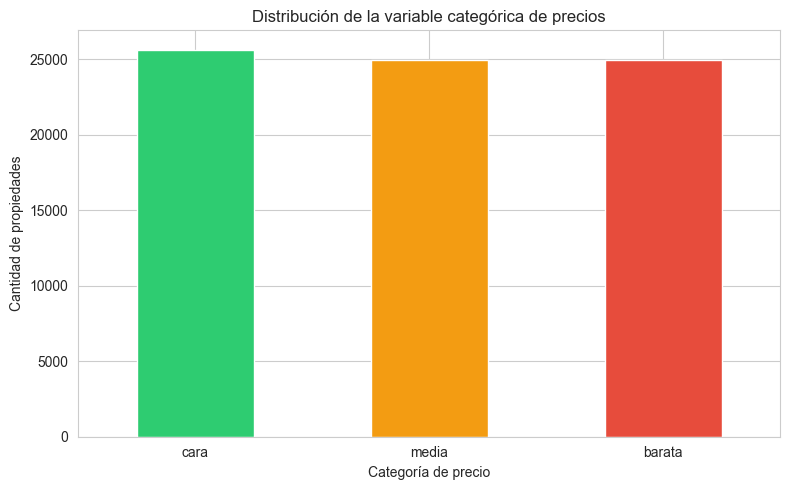

In [52]:
p33 = np.percentile(df['price_num'], 33)
p66 = np.percentile(df['price_num'], 66)
print(f"Punto de corte P33: ${p33:.2f}")
print(f"Punto de corte P66: ${p66:.2f}")

df['price_cat'] = pd.cut(
    df['price_num'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=['barata', 'media', 'cara']
)

print("\nDistribución de la variable categórica:")
print(df['price_cat'].value_counts())

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
df['price_cat'].value_counts().plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'], ax=ax)
ax.set_title('Distribución de la variable categórica de precios')
ax.set_xlabel('Categoría de precio')
ax.set_ylabel('Cantidad de propiedades')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
for col in ['bedrooms', 'beds', 'host_listings_count', 'host_total_listings_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [54]:
# Variables numéricas seleccionadas
nombre_numericas = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'calculated_host_listings_count',
    'latitude', 'longitude',
]

# Variables categóricas seleccionadas
nombre_categoricas = [
    'room_type', 'host_is_superhost',
    'host_identity_verified', 'instant_bookable', 'city',
]

variables_modelo = nombre_numericas + nombre_categoricas
print(f"Total de variables predictoras: {len(variables_modelo)}")
print(f"  - Numéricas: {len(nombre_numericas)}")
print(f"  - Categóricas: {len(nombre_categoricas)}")

Total de variables predictoras: 25
  - Numéricas: 20
  - Categóricas: 5


In [55]:
data = df[variables_modelo].copy()
target = df['price_cat'].copy()

# Reemplazar strings vacíos en categóricas
for col in nombre_categoricas:
    data[col] = data[col].replace('', np.nan)
    data[col] = data[col].fillna('desconocido')

print(f"Dimensiones de data: {data.shape}")
print(f"Dimensiones de target: {target.shape}")
print(f"\nNulos por variable numérica:")
print(data[nombre_numericas].isna().sum())

Dimensiones de data: (75531, 25)
Dimensiones de target: (75531,)

Nulos por variable numérica:
accommodates                          0
bathrooms                            14
bedrooms                            121
beds                                 80
minimum_nights                        0
maximum_nights                        0
availability_30                       0
availability_60                       0
availability_90                       0
availability_365                      0
number_of_reviews                     0
number_of_reviews_ltm                 0
review_scores_rating              12867
review_scores_cleanliness         12871
review_scores_location            12871
review_scores_value               12871
reviews_per_month                 12867
calculated_host_listings_count        0
latitude                              0
longitude                             0
dtype: int64


In [56]:
TAMANIO_MUESTRA = 8000

data_sample, _, target_sample, _ = train_test_split(
    data, target,
    train_size=TAMANIO_MUESTRA,
    stratify=target,
    random_state=SEED
)

print(f"Tamaño de la muestra: {len(data_sample)}")
print("Distribución de clases en la muestra:")
print(target_sample.value_counts(normalize=True).round(3))

Tamaño de la muestra: 8000
Distribución de clases en la muestra:
price_cat
cara      0.339
media     0.331
barata    0.330
Name: proportion, dtype: float64


In [57]:
data_train, data_test, target_train, target_test = train_test_split(
    data_sample, target_sample,
    test_size=0.3,
    train_size=0.7,
    stratify=target_sample,
    random_state=SEED
)

print(f"Conjunto de entrenamiento: {data_train.shape}")
print(f"Conjunto de prueba: {data_test.shape}")
print("\nDistribución en train:")
print(target_train.value_counts(normalize=True).round(3))
print("\nDistribución en test:")
print(target_test.value_counts(normalize=True).round(3))

Conjunto de entrenamiento: (5600, 25)
Conjunto de prueba: (2400, 25)

Distribución en train:
price_cat
cara      0.339
media     0.331
barata    0.330
Name: proportion, dtype: float64

Distribución en test:
price_cat
cara      0.339
media     0.331
barata    0.330
Name: proportion, dtype: float64


In [58]:
preprocesador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

preprocesador_categorico = OneHotEncoder(handle_unknown='ignore')

preprocesador = ColumnTransformer([
    ('num', preprocesador_numerico, nombre_numericas),
    ('cat', preprocesador_categorico, nombre_categoricas),
], remainder='drop')

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [59]:
modelo_lineal = make_pipeline(preprocesador, SVC(kernel='linear', random_state=SEED))

t0 = time.time()
modelo_lineal.fit(data_train, target_train)
tiempo_lineal = time.time() - t0
print(f"Tiempo de entrenamiento (lineal): {tiempo_lineal:.2f} s")

pred_train_lineal = modelo_lineal.predict(data_train)
pred_test_lineal = modelo_lineal.predict(data_test)

acc_train_lineal = accuracy_score(target_train, pred_train_lineal)
acc_test_lineal = accuracy_score(target_test, pred_test_lineal)
print(f"Accuracy en train: {acc_train_lineal:.4f}")
print(f"Accuracy en test : {acc_test_lineal:.4f}")

Tiempo de entrenamiento (lineal): 0.93 s
Accuracy en train: 0.6641
Accuracy en test : 0.6521


In [60]:
modelo_poly = make_pipeline(preprocesador, SVC(kernel='poly', degree=3, random_state=SEED))

t0 = time.time()
modelo_poly.fit(data_train, target_train)
tiempo_poly = time.time() - t0
print(f"Tiempo de entrenamiento (polinomial): {tiempo_poly:.2f} s")

pred_train_poly = modelo_poly.predict(data_train)
pred_test_poly = modelo_poly.predict(data_test)

acc_train_poly = accuracy_score(target_train, pred_train_poly)
acc_test_poly = accuracy_score(target_test, pred_test_poly)
print(f"Accuracy en train: {acc_train_poly:.4f}")
print(f"Accuracy en test : {acc_test_poly:.4f}")

Tiempo de entrenamiento (polinomial): 0.57 s
Accuracy en train: 0.7330
Accuracy en test : 0.6579


In [61]:
modelo_rbf = make_pipeline(preprocesador, SVC(kernel='rbf', random_state=SEED))

t0 = time.time()
modelo_rbf.fit(data_train, target_train)
tiempo_rbf = time.time() - t0
print(f"Tiempo de entrenamiento (RBF): {tiempo_rbf:.2f} s")

pred_train_rbf = modelo_rbf.predict(data_train)
pred_test_rbf = modelo_rbf.predict(data_test)

acc_train_rbf = accuracy_score(target_train, pred_train_rbf)
acc_test_rbf = accuracy_score(target_test, pred_test_rbf)
print(f"Accuracy en train: {acc_train_rbf:.4f}")
print(f"Accuracy en test : {acc_test_rbf:.4f}")

Tiempo de entrenamiento (RBF): 0.58 s
Accuracy en train: 0.7320
Accuracy en test : 0.6637


In [62]:
param_grid_lineal = {
    'svc__C': [0.01, 0.1, 1, 10],
}

modelo_lineal_base = make_pipeline(preprocesador, SVC(kernel='linear', random_state=SEED))

t0 = time.time()
grid_lineal = GridSearchCV(
    modelo_lineal_base, param_grid=param_grid_lineal,
    cv=5, n_jobs=-1, scoring='accuracy'
)
grid_lineal.fit(data_train, target_train)
tiempo_grid_lineal = time.time() - t0

print(f"Tiempo de tuneo (lineal): {tiempo_grid_lineal:.2f} s")
print(f"Mejores parámetros: {grid_lineal.best_params_}")
print(f"Mejor accuracy CV: {grid_lineal.best_score_:.4f}")
print(f"Accuracy en test : {grid_lineal.score(data_test, target_test):.4f}")

Tiempo de tuneo (lineal): 16.84 s
Mejores parámetros: {'svc__C': 10}
Mejor accuracy CV: 0.6539
Accuracy en test : 0.6517


In [63]:
param_grid_poly = {
    'svc__C': [0.1, 1, 10],
    'svc__degree': [2, 3, 4],
    'svc__gamma': ['scale', 'auto'],
}

modelo_poly_base = make_pipeline(preprocesador, SVC(kernel='poly', random_state=SEED))

t0 = time.time()
grid_poly = GridSearchCV(
    modelo_poly_base, param_grid=param_grid_poly,
    cv=5, n_jobs=-1, scoring='accuracy'
)
grid_poly.fit(data_train, target_train)
tiempo_grid_poly = time.time() - t0

print(f"Tiempo de tuneo (polinomial): {tiempo_grid_poly:.2f} s")
print(f"Mejores parámetros: {grid_poly.best_params_}")
print(f"Mejor accuracy CV: {grid_poly.best_score_:.4f}")
print(f"Accuracy en test : {grid_poly.score(data_test, target_test):.4f}")


Tiempo de tuneo (polinomial): 8.16 s
Mejores parámetros: {'svc__C': 10, 'svc__degree': 2, 'svc__gamma': 'scale'}
Mejor accuracy CV: 0.6736
Accuracy en test : 0.6683


In [64]:
param_grid_rbf = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 'scale'],
}

modelo_rbf_base = make_pipeline(preprocesador, SVC(kernel='rbf', random_state=SEED))

t0 = time.time()
grid_rbf = GridSearchCV(
    modelo_rbf_base, param_grid=param_grid_rbf,
    cv=5, n_jobs=-1, scoring='accuracy'
)
grid_rbf.fit(data_train, target_train)
tiempo_grid_rbf = time.time() - t0

print(f"Tiempo de tuneo (RBF): {tiempo_grid_rbf:.2f} s")
print(f"Mejores parámetros: {grid_rbf.best_params_}")
print(f"Mejor accuracy CV: {grid_rbf.best_score_:.4f}")
print(f"Accuracy en test : {grid_rbf.score(data_test, target_test):.4f}")


Tiempo de tuneo (RBF): 11.04 s
Mejores parámetros: {'svc__C': 10, 'svc__gamma': 'scale'}
Mejor accuracy CV: 0.6764
Accuracy en test : 0.6687


In [65]:
cv_results_rbf = pd.DataFrame(grid_rbf.cv_results_)[
    ['param_svc__C', 'param_svc__gamma','mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10)
cv_results_rbf


,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
11,10.0,scale,0.676429,0.009952,1
13,100.0,0.01,0.676250,0.011880,2
9,10.0,0.01,0.674107,0.009600,3
6,1.0,0.1,0.673929,0.007521,4
7,1.0,scale,0.673750,0.009872,5
12,100.0,0.001,0.669821,0.008249,6
10,10.0,0.1,0.658571,0.016284,7
5,1.0,0.01,0.655893,0.007547,8
8,10.0,0.001,0.647321,0.012963,9
14,100.0,0.1,0.638929,0.012860,10


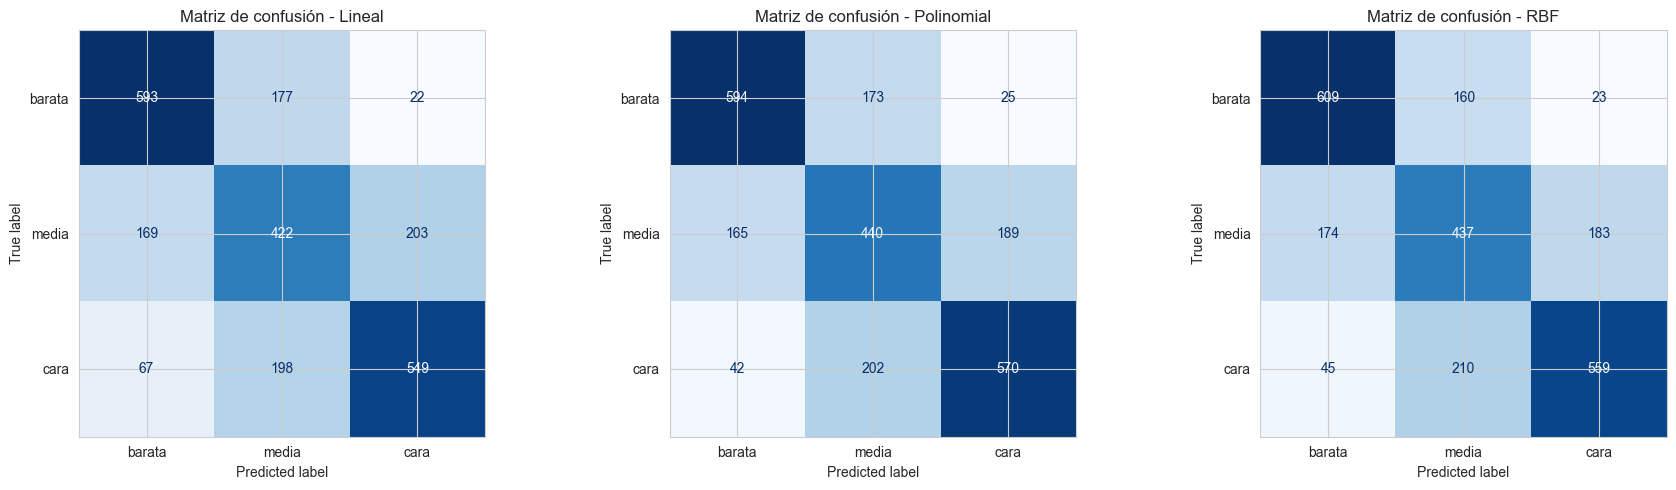

In [66]:
mejores_modelos = {
    'Lineal': grid_lineal.best_estimator_,
    'Polinomial': grid_poly.best_estimator_,
    'RBF': grid_rbf.best_estimator_,
}

# Predicciones
predicciones = {nombre: m.predict(data_test) for nombre, m in mejores_modelos.items()}

# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clases = ['barata', 'media', 'cara']
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(target_test, pred, labels=clases)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de confusión - {nombre}')
plt.tight_layout()
plt.show()


In [67]:
for nombre, pred in predicciones.items():
 print(f"\n{'='*60}")
 print(f"REPORTE DE CLASIFICACIÓN - Kernel {nombre}")
 print('='*60)
 print(classification_report(target_test, pred, digits=4))


REPORTE DE CLASIFICACIÓN - Kernel Lineal
              precision    recall  f1-score   support

      barata     0.7153    0.7487    0.7316       792
        cara     0.7093    0.6744    0.6914       814
       media     0.5295    0.5315    0.5305       794

    accuracy                         0.6517      2400
   macro avg     0.6514    0.6516    0.6512      2400
weighted avg     0.6518    0.6517    0.6515      2400


REPORTE DE CLASIFICACIÓN - Kernel Polinomial
              precision    recall  f1-score   support

      barata     0.7416    0.7500    0.7458       792
        cara     0.7270    0.7002    0.7134       814
       media     0.5399    0.5542    0.5469       794

    accuracy                         0.6683      2400
   macro avg     0.6695    0.6681    0.6687      2400
weighted avg     0.6699    0.6683    0.6690      2400


REPORTE DE CLASIFICACIÓN - Kernel RBF
              precision    recall  f1-score   support

      barata     0.7355    0.7689    0.7519       792
  

In [68]:
filas = []
for nombre, modelo in mejores_modelos.items():
    pred_train = modelo.predict(data_train)
    pred_test = modelo.predict(data_test)
    
    acc_train = accuracy_score(target_train, pred_train)
    acc_test = accuracy_score(target_test, pred_test)
    f1_train = f1_score(target_train, pred_train, average='weighted')
    f1_test = f1_score(target_test, pred_test, average='weighted')
    
    # Validación cruzada
    cv_scores = cross_val_score(modelo, data_train, target_train, cv=5, n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    brecha = acc_train - acc_test
    
    filas.append({
        'Kernel': nombre,
        'Acc Train': round(acc_train, 4),
        'Acc Test': round(acc_test, 4),
        'F1 Train': round(f1_train, 4),
        'F1 Test': round(f1_test, 4),
        'CV mean': round(cv_mean, 4),
        'CV std': round(cv_std, 4),
        'Brecha (Train-Test)': round(brecha, 4),
    })

tabla_ajuste = pd.DataFrame(filas)
tabla_ajuste

,Kernel,Acc Train,Acc Test,F1 Train,F1 Test,CV mean,CV std,Brecha (Train-Test)
0,Lineal,0.6641,0.6517,0.6655,0.6515,0.6539,0.0065,0.0124
1,Polinomial,0.7411,0.6683,0.7424,0.6690,0.6736,0.0077,0.0727
2,RBF,0.8320,0.6687,0.8329,0.6689,0.6764,0.0100,0.1632


In [69]:
resumen_modelos = []
tiempos = {'Lineal': tiempo_grid_lineal, 'Polinomial': tiempo_grid_poly, 'RBF': tiempo_grid_rbf}

for nombre, modelo in mejores_modelos.items():
    pred = modelo.predict(data_test)
    resumen_modelos.append({
        'Kernel': nombre,
        'Accuracy': round(accuracy_score(target_test, pred), 4),
        'Precision (weighted)': round(precision_score(target_test, pred, average='weighted'), 4),
        'Recall (weighted)': round(recall_score(target_test, pred, average='weighted'), 4),
        'F1 (weighted)': round(f1_score(target_test, pred, average='weighted'), 4),
        'Tiempo tuneo (s)': round(tiempos[nombre], 2),
    })

resumen_df = pd.DataFrame(resumen_modelos)
resumen_df

,Kernel,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),Tiempo tuneo (s)
0,Lineal,0.6517,0.6518,0.6517,0.6515,16.84
1,Polinomial,0.6683,0.6699,0.6683,0.6690,8.16
2,RBF,0.6687,0.6697,0.6687,0.6689,11.04


In [70]:
for nombre, pred in predicciones.items():
    cm = confusion_matrix(target_test, pred, labels=clases)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    print(f"\n--- {nombre} (matriz normalizada por fila) ---")
    print(pd.DataFrame(cm_norm.round(3), index=clases, columns=clases))


--- Lineal (matriz normalizada por fila) ---
        barata  media   cara
barata   0.749  0.223  0.028
media    0.213  0.531  0.256
cara     0.082  0.243  0.674

--- Polinomial (matriz normalizada por fila) ---
        barata  media   cara
barata   0.750  0.218  0.032
media    0.208  0.554  0.238
cara     0.052  0.248  0.700

--- RBF (matriz normalizada por fila) ---
        barata  media   cara
barata   0.769  0.202  0.029
media    0.219  0.550  0.230
cara     0.055  0.258  0.687


In [71]:
##incisos 8 al 13 

In [72]:
# Muestra para REGRESIÓN (18000)
TAMANIO_REG = 18000
data_reg_sample, _, target_reg_sample, _ = train_test_split(
    data, df.loc[data.index, 'price_num'],
    train_size=TAMANIO_REG,
    random_state=SEED
)
data_train_reg, data_test_reg, target_reg_train, target_reg_test = train_test_split(
    data_reg_sample, target_reg_sample,
    test_size=0.3, train_size=0.7,
    random_state=SEED
)
print(f"REGRESIÓN — Train: {data_train_reg.shape} | Test: {data_test_reg.shape}")

REGRESIÓN — Train: (12600, 25) | Test: (5400, 25)


In [73]:
mejores_svm = {
    'SVM Lineal': mejores_modelos['Lineal'],
    'SVM Polinomial': mejores_modelos['Polinomial'],
    'SVM RBF': mejores_modelos['RBF'],
}
tiempos_svm = {
    'SVM Lineal': tiempo_grid_lineal,
    'SVM Polinomial': tiempo_grid_poly,
    'SVM RBF': tiempo_grid_rbf,
}
##renombre de splits para clasificación
data_train_clas = data_train
data_test_clas = data_test
target_clase_train = target_train
target_clase_test = target_test

In [74]:
##analisis comparativo entre los kernels de svm 
clases = ['barata', 'media', 'cara']

filas_comp = []
for nombre, modelo in mejores_svm.items():
    pred_train = modelo.predict(data_train_clas)
    pred_test = modelo.predict(data_test_clas)
    filas_comp.append({
        'Modelo': nombre,
        'Acc Train': round(accuracy_score(target_clase_train, pred_train), 4),
        'Acc Test': round(accuracy_score(target_clase_test, pred_test), 4),
        'Precision': round(precision_score(target_clase_test, pred_test, average='weighted'), 4),
        'Recall': round(recall_score(target_clase_test, pred_test, average='weighted'), 4),
        'F1': round(f1_score(target_clase_test, pred_test, average='weighted'), 4),
        'Brecha (T-V)': round(accuracy_score(target_clase_train, pred_train) -
                              accuracy_score(target_clase_test, pred_test), 4),
        'Tiempo (s)': round(tiempos_svm[nombre], 2),
    })
comparacion_svm = pd.DataFrame(filas_comp)
comparacion_svm

,Modelo,Acc Train,Acc Test,Precision,Recall,F1,Brecha (T-V),Tiempo (s)
0,SVM Lineal,0.6641,0.6517,0.6518,0.6517,0.6515,0.0124,16.84
1,SVM Polinomial,0.7411,0.6683,0.6699,0.6683,0.6690,0.0727,8.16
2,SVM RBF,0.8320,0.6687,0.6697,0.6687,0.6689,0.1632,11.04


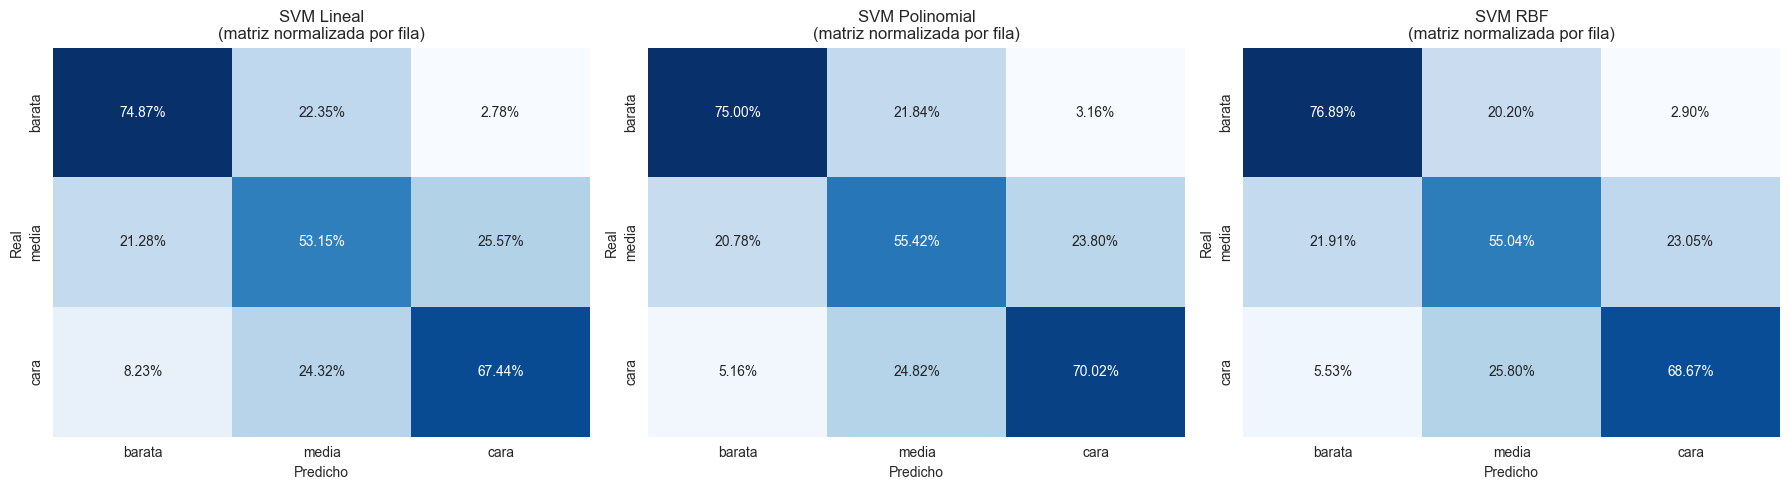

In [75]:
## Errores por clase  
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, modelo) in zip(axes, mejores_svm.items()):
    pred = modelo.predict(data_test_clas)
    cm = confusion_matrix(target_clase_test, pred, labels=clases)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=clases, yticklabels=clases, ax=ax, cbar=False)
    ax.set_title(f'{nombre}\n(matriz normalizada por fila)')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

In [76]:
print("=" * 70)
print("ERRORES GRAVES (cara confundida con barata o viceversa)")
print("=" * 70)
for nombre, modelo in mejores_svm.items():
    pred = modelo.predict(data_test_clas)
    cm = confusion_matrix(target_clase_test, pred, labels=clases)
    error_cara_barata = cm[2][0]
    error_barata_cara = cm[0][2]
    total_grave = error_cara_barata + error_barata_cara
    total = cm.sum()
    print(f"{nombre:18s} | Cara→Barata: {error_cara_barata:3d} | "
          f"Barata→Cara: {error_barata_cara:3d} | "
          f"Total graves: {total_grave:3d} ({total_grave/total*100:.2f}%)")

ERRORES GRAVES (cara confundida con barata o viceversa)
SVM Lineal         | Cara→Barata:  67 | Barata→Cara:  22 | Total graves:  89 (3.71%)
SVM Polinomial     | Cara→Barata:  42 | Barata→Cara:  25 | Total graves:  67 (2.79%)
SVM RBF            | Cara→Barata:  45 | Barata→Cara:  23 | Total graves:  68 (2.83%)


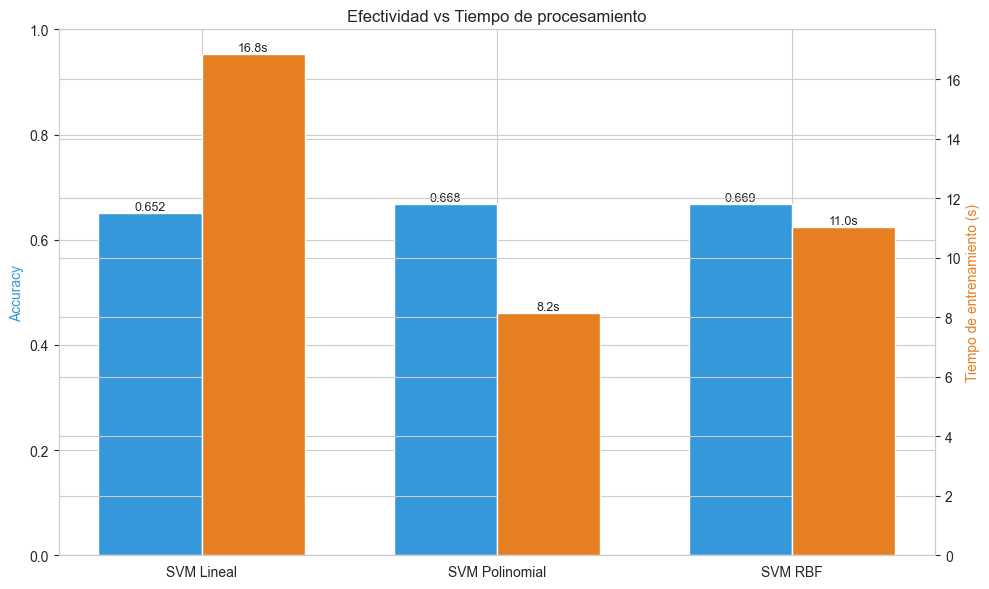

In [77]:
## Comparacion tiempos contra efectividad
fig, ax = plt.subplots(figsize=(10, 6))
df_plot = comparacion_svm.set_index('Modelo')
ax2 = ax.twinx()

x = np.arange(len(df_plot))
ancho = 0.35

ax.bar(x - ancho/2, df_plot['Acc Test'], ancho, label='Accuracy Test', color='#3498db')
ax2.bar(x + ancho/2, df_plot['Tiempo (s)'], ancho, label='Tiempo (s)', color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index)
ax.set_ylabel('Accuracy', color='#3498db')
ax2.set_ylabel('Tiempo de entrenamiento (s)', color='#e67e22')
ax.set_title('Efectividad vs Tiempo de procesamiento')
ax.set_ylim(0, 1)

for i, (acc, tiempo) in enumerate(zip(df_plot['Acc Test'], df_plot['Tiempo (s)'])):
    ax.annotate(f'{acc:.3f}', xy=(i - ancho/2, acc), ha='center', va='bottom', fontsize=9)
    ax2.annotate(f'{tiempo:.1f}s', xy=(i + ancho/2, tiempo), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [78]:
## Comparacion de modelos de otros labs 

In [79]:
# Métricas de cada modelo entrenado bajo las mismas condiciones
# de train/test (mismo split, misma variable respuesta triclase).
resultados_clas = [
    {'Modelo': 'Naive Bayes',
     'Acc Train': 0.5225, 'Acc Test': 0.5217,
     'Precision': 0.62, 'Recall': 0.52, 'F1': 0.51,
     'Tiempo (s)': 0.0016},
    
    {'Modelo': 'Árbol de Decisión',
     'Acc Train': 0.6800, 'Acc Test': 0.6079,
     'Precision': 0.60, 'Recall': 0.61, 'F1': 0.60,
     'Tiempo (s)': 0.1475},
    
    {'Modelo': 'Random Forest',
     'Acc Train': 0.8800, 'Acc Test': 0.6218,
     'Precision': 0.61, 'Recall': 0.62, 'F1': 0.62,
     'Tiempo (s)': 0.8062},
    
    {'Modelo': 'KNN (k=25)',
     'Acc Train': 0.6400, 'Acc Test': 0.6256,
     'Precision': 0.62, 'Recall': 0.63, 'F1': 0.62,
     'Tiempo (s)': 0.0500},
    
    {'Modelo': 'Regresión Logística',
     'Acc Train': 0.7890, 'Acc Test': 0.7938,
     'Precision': 0.79, 'Recall': 0.79, 'F1': 0.75,
     'Tiempo (s)': 0.2000},
]

# Mejor SVM (RBF) calculado en este lab
pred_train_rbf = mejores_svm['SVM RBF'].predict(data_train_clas)
pred_test_rbf = mejores_svm['SVM RBF'].predict(data_test_clas)
resultados_clas.append({
    'Modelo': 'SVM RBF',
    'Acc Train': round(accuracy_score(target_clase_train, pred_train_rbf), 4),
    'Acc Test': round(accuracy_score(target_clase_test, pred_test_rbf), 4),
    'Precision': round(precision_score(target_clase_test, pred_test_rbf, average='weighted'), 4),
    'Recall': round(recall_score(target_clase_test, pred_test_rbf, average='weighted'), 4),
    'F1': round(f1_score(target_clase_test, pred_test_rbf, average='weighted'), 4),
    'Tiempo (s)': round(tiempos_svm['SVM RBF'], 2),
})

tabla_comp_clas = pd.DataFrame(resultados_clas).sort_values('Acc Test', ascending=False)
tabla_comp_clas

,Modelo,Acc Train,Acc Test,Precision,Recall,F1,Tiempo (s)
4,Regresión Logística,0.7890,0.7938,0.7900,0.7900,0.7500,0.2000
5,SVM RBF,0.8320,0.6687,0.6697,0.6687,0.6689,11.0400
3,KNN (k=25),0.6400,0.6256,0.6200,0.6300,0.6200,0.0500
2,Random Forest,0.8800,0.6218,0.6100,0.6200,0.6200,0.8062
1,Árbol de Decisión,0.6800,0.6079,0.6000,0.6100,0.6000,0.1475
0,Naive Bayes,0.5225,0.5217,0.6200,0.5200,0.5100,0.0016


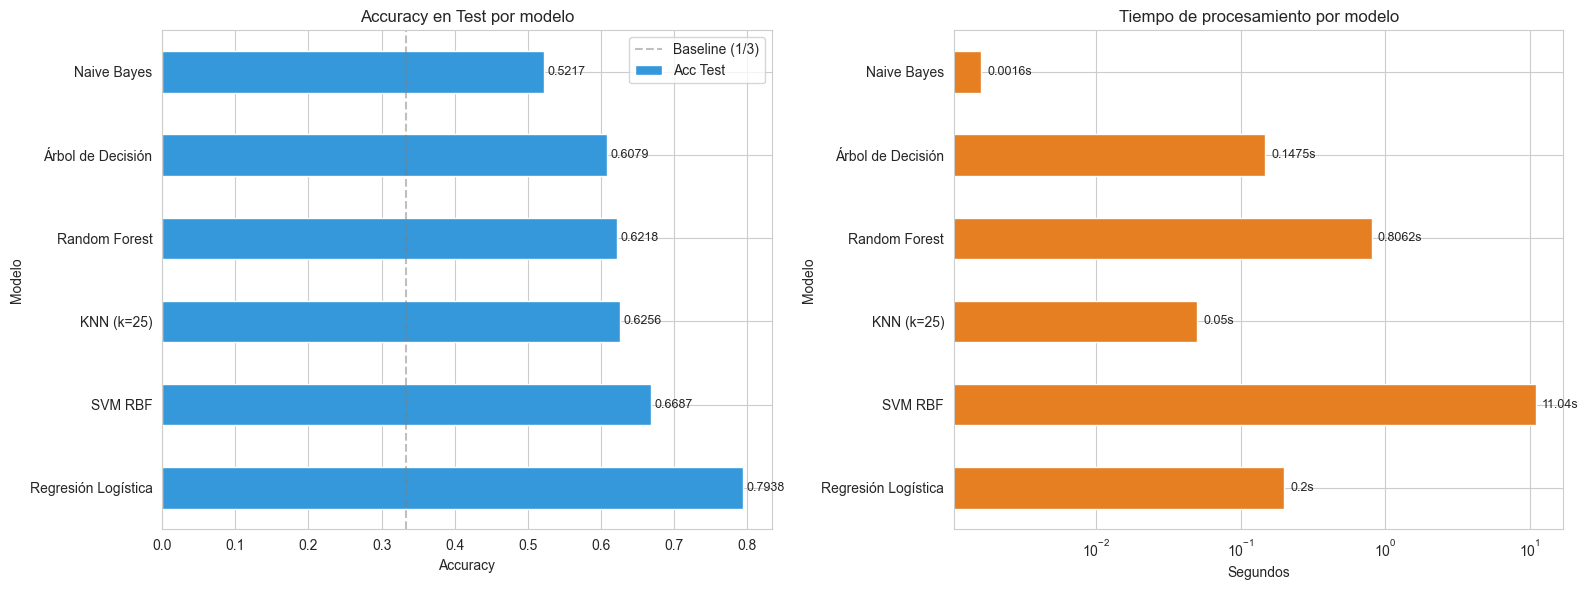

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = tabla_comp_clas.set_index('Modelo')

# Accuracy
df_plot['Acc Test'].plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Accuracy en Test por modelo')
axes[0].set_xlabel('Accuracy')
axes[0].axvline(x=0.333, color='gray', linestyle='--', alpha=0.5, label='Baseline (1/3)')
for i, v in enumerate(df_plot['Acc Test']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
axes[0].legend()

# Tiempo
df_plot['Tiempo (s)'].plot(kind='barh', ax=axes[1], color='#e67e22')
axes[1].set_title('Tiempo de procesamiento por modelo')
axes[1].set_xlabel('Segundos')
axes[1].set_xscale('log')
for i, v in enumerate(df_plot['Tiempo (s)']):
    axes[1].text(v * 1.1, i, f'{v}s', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [81]:
def diagnosticar_ajuste(acc_train, acc_test):
    brecha = acc_train - acc_test
    if acc_train < 0.65 and acc_test < 0.65:
        return "Subajuste"
    if brecha < 0.03:
        return "Buen ajuste"
    elif brecha < 0.10:
        return "Sobreajuste leve"
    else:
        return "Sobreajuste claro"

# Construir tabla con todos los modelos
filas_ajuste = []
for r in resultados_clas:
    acc_t = r['Acc Train']
    acc_v = r['Acc Test']
    brecha = acc_t - acc_v
    brecha_rel = brecha / acc_t * 100 if acc_t > 0 else 0
    filas_ajuste.append({
        'Modelo': r['Modelo'],
        'Acc Train': round(acc_t, 4),
        'Acc Test': round(acc_v, 4),
        'Brecha': round(brecha, 4),
        'Brecha rel.': f"{brecha_rel:.1f}%",
        'Diagnóstico': diagnosticar_ajuste(acc_t, acc_v),
    })

tabla_ajuste = pd.DataFrame(filas_ajuste).sort_values('Brecha', ascending=False)
tabla_ajuste

,Modelo,Acc Train,Acc Test,Brecha,Brecha rel.,Diagnóstico
2,Random Forest,0.8800,0.6218,0.2582,29.3%,Sobreajuste claro
5,SVM RBF,0.8320,0.6687,0.1633,19.6%,Sobreajuste claro
1,Árbol de Decisión,0.6800,0.6079,0.0721,10.6%,Sobreajuste leve
3,KNN (k=25),0.6400,0.6256,0.0144,2.2%,Subajuste
0,Naive Bayes,0.5225,0.5217,0.0008,0.2%,Subajuste
4,Regresión Logística,0.7890,0.7938,-0.0048,-0.6%,Buen ajuste


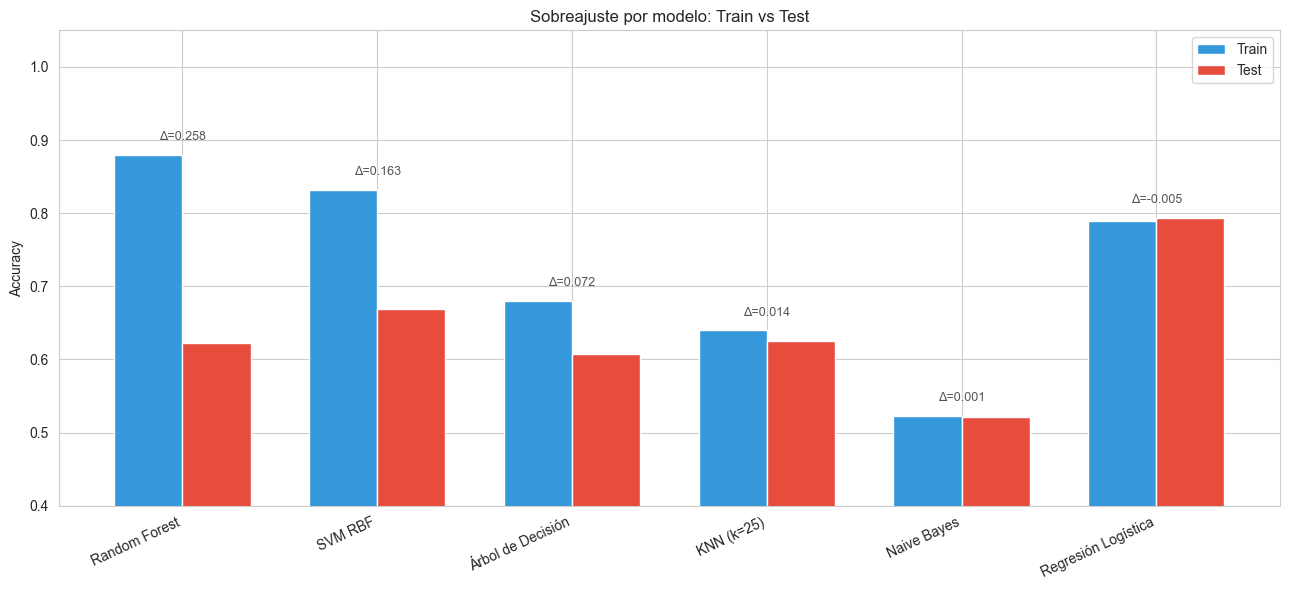

In [82]:
fig, ax = plt.subplots(figsize=(13, 6))
df_plot = tabla_ajuste.set_index('Modelo')
x = np.arange(len(df_plot))
ancho = 0.35

ax.bar(x - ancho/2, df_plot['Acc Train'], ancho, label='Train', color='#3498db')
ax.bar(x + ancho/2, df_plot['Acc Test'], ancho, label='Test', color='#e74c3c')

for i, brecha in enumerate(df_plot['Brecha']):
    max_acc = max(df_plot['Acc Train'].iloc[i], df_plot['Acc Test'].iloc[i])
    ax.annotate(f'Δ={brecha:.3f}',
                xy=(i, max_acc + 0.02),
                ha='center', fontsize=9, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=25, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Sobreajuste por modelo: Train vs Test')
ax.legend()
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

In [83]:
target_reg_train_log = np.log1p(target_reg_train)
target_reg_test_log = np.log1p(target_reg_test)

print(f"Distribución del precio original:")
print(target_reg_train.describe().round(2))
print(f"\nDistribución de log(precio + 1):")
print(target_reg_train_log.describe().round(2))

Distribución del precio original:
count    12600.00
mean       346.06
std        837.60
min         11.00
25%        119.00
50%        191.00
75%        319.00
max      20000.00
Name: price_num, dtype: float64

Distribución de log(precio + 1):
count    12600.00
mean         5.33
std          0.86
min          2.48
25%          4.79
50%          5.26
75%          5.77
max          9.90
Name: price_num, dtype: float64


In [84]:
print("Entrenando SVR base (RBF)...")
t0 = time.time()
svr_base = make_pipeline(
    preprocesador,
    SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)
)
svr_base.fit(data_train_reg, target_reg_train_log)
tiempo_svr_base = time.time() - t0
print(f"Tiempo: {tiempo_svr_base:.2f}s")

pred_train_svr = np.expm1(svr_base.predict(data_train_reg))
pred_test_svr = np.expm1(svr_base.predict(data_test_reg))

print(f"\nSVR base (escala original USD):")
print(f"  R²  Train : {r2_score(target_reg_train, pred_train_svr):.4f}")
print(f"  R²  Test  : {r2_score(target_reg_test, pred_test_svr):.4f}")
print(f"  RMSE Test : ${np.sqrt(mean_squared_error(target_reg_test, pred_test_svr)):.2f}")
print(f"  MAE  Test : ${mean_absolute_error(target_reg_test, pred_test_svr):.2f}")

Entrenando SVR base (RBF)...
Tiempo: 3.87s

SVR base (escala original USD):
  R²  Train : 0.3310
  R²  Test  : 0.2201
  RMSE Test : $718.29
  MAE  Test : $145.46


In [85]:
param_grid_svr = {
    'svr__C': [0.1, 1, 10],
    'svr__gamma': ['scale', 0.01],
    'svr__epsilon': [0.05, 0.1, 0.2],
}

svr_pipe = Pipeline([
    ('preprocesador', preprocesador),
    ('svr', SVR(kernel='rbf'))
])

print("Tuneando SVR con GridSearchCV (puede tardar varios minutos)...")
t0 = time.time()
grid_svr = GridSearchCV(
    svr_pipe, param_grid=param_grid_svr,
    cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error'
)
grid_svr.fit(data_train_reg, target_reg_train_log)
tiempo_grid_svr = time.time() - t0

print(f"\nTiempo de tuneo: {tiempo_grid_svr:.2f}s")
print(f"Mejores parámetros: {grid_svr.best_params_}")

mejor_svr = grid_svr.best_estimator_
pred_train_svr_tun = np.expm1(mejor_svr.predict(data_train_reg))
pred_test_svr_tun = np.expm1(mejor_svr.predict(data_test_reg))

r2_train_svr = r2_score(target_reg_train, pred_train_svr_tun)
r2_test_svr = r2_score(target_reg_test, pred_test_svr_tun)
rmse_svr = np.sqrt(mean_squared_error(target_reg_test, pred_test_svr_tun))
mae_svr = mean_absolute_error(target_reg_test, pred_test_svr_tun)

print(f"\nSVR tuneado (escala original USD):")
print(f"  R²  Train : {r2_train_svr:.4f}")
print(f"  R²  Test  : {r2_test_svr:.4f}")
print(f"  RMSE Test : ${rmse_svr:.2f}")
print(f"  MAE  Test : ${mae_svr:.2f}")

Tuneando SVR con GridSearchCV (puede tardar varios minutos)...

Tiempo de tuneo: 48.02s
Mejores parámetros: {'svr__C': 10, 'svr__epsilon': 0.2, 'svr__gamma': 'scale'}

SVR tuneado (escala original USD):
  R²  Train : 0.4304
  R²  Test  : 0.2597
  RMSE Test : $699.82
  MAE  Test : $143.38


In [86]:
cv_results = pd.DataFrame(grid_svr.cv_results_)
top_resultados = cv_results[
    ['param_svr__C', 'param_svr__gamma', 'param_svr__epsilon',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10).copy()
top_resultados['mean_test_RMSE'] = -top_resultados['mean_test_score']
top_resultados.drop(columns=['mean_test_score'])

,param_svr__C,param_svr__gamma,param_svr__epsilon,std_test_score,rank_test_score,mean_test_RMSE
16,10.0,scale,0.20,0.011066,1,0.504143
8,1.0,scale,0.10,0.016051,2,0.507328
14,10.0,scale,0.10,0.010817,3,0.507400
10,1.0,scale,0.20,0.016765,4,0.507508
6,1.0,scale,0.05,0.015989,5,0.507692
15,10.0,0.01,0.10,0.014456,6,0.508013
17,10.0,0.01,0.20,0.014771,7,0.508666
13,10.0,0.01,0.05,0.014540,8,0.509309
12,10.0,scale,0.05,0.009986,9,0.509914
11,1.0,0.01,0.20,0.017710,10,0.529264


In [87]:
cv_results = pd.DataFrame(grid_svr.cv_results_)
top_resultados = cv_results[
    ['param_svr__C', 'param_svr__gamma', 'param_svr__epsilon','mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10).copy()
top_resultados['mean_test_RMSE'] = -top_resultados['mean_test_score']
top_resultados.drop(columns=['mean_test_score'])

,param_svr__C,param_svr__gamma,param_svr__epsilon,std_test_score,rank_test_score,mean_test_RMSE
16,10.0,scale,0.20,0.011066,1,0.504143
8,1.0,scale,0.10,0.016051,2,0.507328
14,10.0,scale,0.10,0.010817,3,0.507400
10,1.0,scale,0.20,0.016765,4,0.507508
6,1.0,scale,0.05,0.015989,5,0.507692
15,10.0,0.01,0.10,0.014456,6,0.508013
17,10.0,0.01,0.20,0.014771,7,0.508666
13,10.0,0.01,0.05,0.014540,8,0.509309
12,10.0,scale,0.05,0.009986,9,0.509914
11,1.0,0.01,0.20,0.017710,10,0.529264


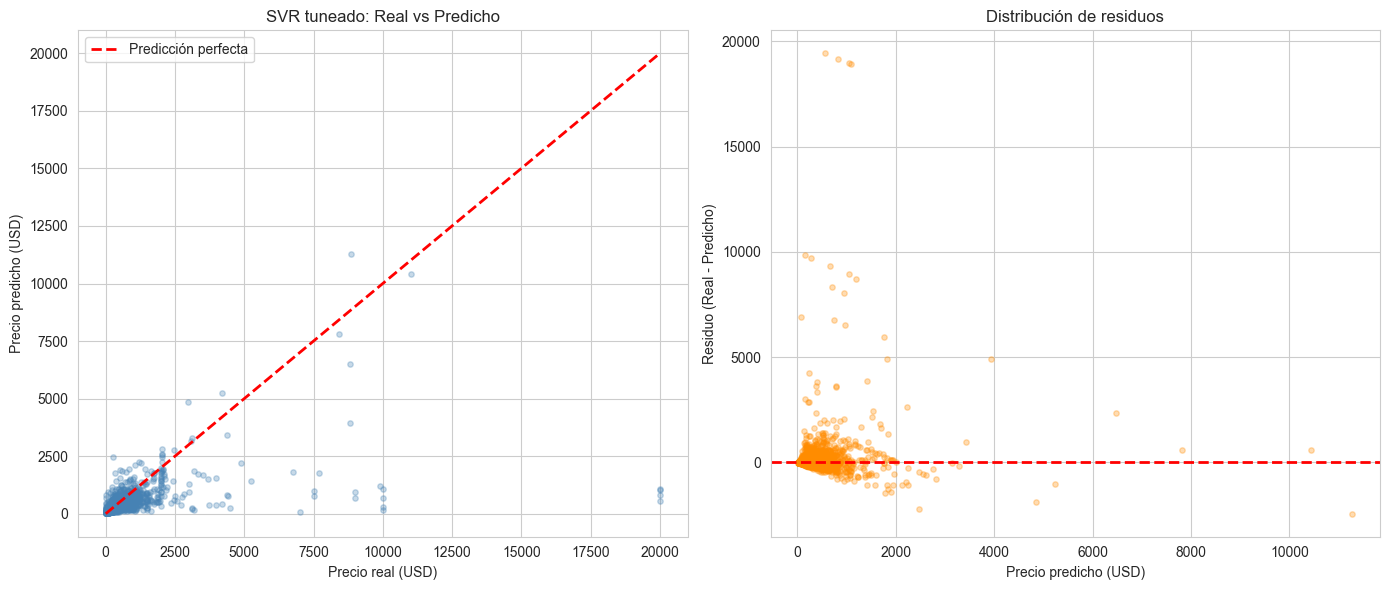

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(target_reg_test, pred_test_svr_tun, alpha=0.3, s=15, color='steelblue')
maxv = max(target_reg_test.max(), pred_test_svr_tun.max())
axes[0].plot([0, maxv], [0, maxv], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (USD)')
axes[0].set_ylabel('Precio predicho (USD)')
axes[0].set_title('SVR tuneado: Real vs Predicho')
axes[0].legend()

residuos = target_reg_test - pred_test_svr_tun
axes[1].scatter(pred_test_svr_tun, residuos, alpha=0.3, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Precio predicho (USD)')
axes[1].set_ylabel('Residuo (Real - Predicho)')
axes[1].set_title('Distribución de residuos')

plt.tight_layout()
plt.show()

In [89]:
brecha_svr = r2_train_svr - r2_test_svr
print(f"R² Train: {r2_train_svr:.4f}")
print(f"R² Test:  {r2_test_svr:.4f}")
print(f"Brecha:   {brecha_svr:.4f}")

if brecha_svr < 0.05:
    print("Diagnóstico: Buen ajuste — el modelo generaliza bien.")
elif brecha_svr < 0.15:
    print("Diagnóstico: Sobreajuste leve.")
else:
    print("Diagnóstico: Sobreajuste claro.")

R² Train: 0.4304
R² Test:  0.2597
Brecha:   0.1706
Diagnóstico: Sobreajuste claro.


In [91]:
# Métricas de cada modelo entrenado bajo las mismas condiciones
resultados_reg = [
    {'Modelo': 'Regresión Lineal',
    'R² Train': 0.190, 'R² Test': 0.184,
    'RMSE Test': 432.54, 'MAE Test': 161.29,
    'Tiempo (s)': 0.05},
    
    {'Modelo': 'Árbol de Regresión',
    'R² Train': 0.260, 'R² Test': 0.233,
    'RMSE Test': 419.29, 'MAE Test': 148.35,
    'Tiempo (s)': 0.20},
    
    {'Modelo': 'Naive Bayes',
    'R² Train': 0.1093, 'R² Test': 0.1074,
    'RMSE Test': 452.44, 'MAE Test': 155.78,
    'Tiempo (s)': 0.005},
    
    {'Modelo': 'KNN (k=20)',
    'R² Train': 0.560, 'R² Test': 0.5189,
    'RMSE Test': 175.60, 'MAE Test': 103.83,
    'Tiempo (s)': 0.50},
]


In [92]:
# SVR tuneado de este lab
resultados_reg.append({
    'Modelo': 'SVR (RBF tuneado)',
    'R² Train': round(r2_train_svr, 4),
    'R² Test': round(r2_test_svr, 4),
    'RMSE Test': round(rmse_svr, 2),
    'MAE Test': round(mae_svr, 2),
    'Tiempo (s)': round(tiempo_grid_svr, 2),
})

tabla_comp_reg = pd.DataFrame(resultados_reg).sort_values('R² Test', ascending=False)
tabla_comp_reg

,Modelo,R² Train,R² Test,RMSE Test,MAE Test,Tiempo (s)
3,KNN (k=20),0.5600,0.5189,175.60,103.83,0.500
4,SVR (RBF tuneado),0.4304,0.2597,699.82,143.38,48.020
1,Árbol de Regresión,0.2600,0.2330,419.29,148.35,0.200
0,Regresión Lineal,0.1900,0.1840,432.54,161.29,0.050
2,Naive Bayes,0.1093,0.1074,452.44,155.78,0.005


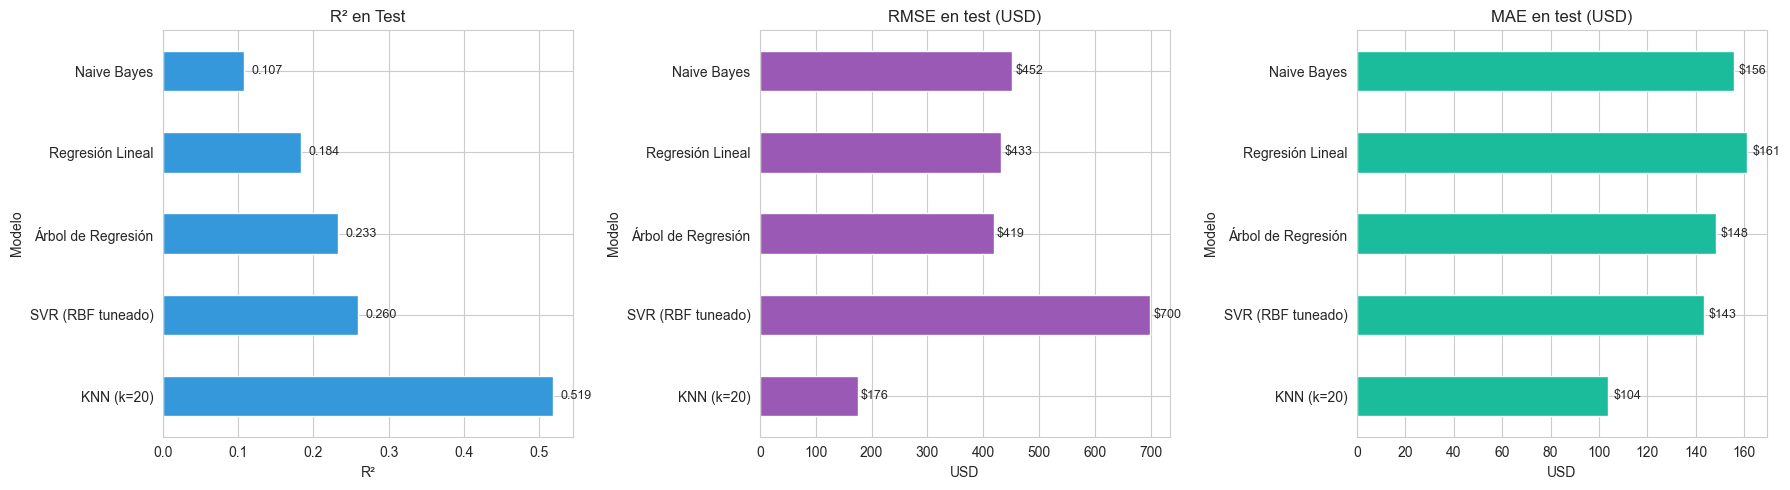

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df_plot_r = tabla_comp_reg.set_index('Modelo')

df_plot_r['R² Test'].plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('R² en Test')
axes[0].set_xlabel('R²')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(df_plot_r['R² Test']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

df_plot_r['RMSE Test'].plot(kind='barh', ax=axes[1], color='#9b59b6')
axes[1].set_title('RMSE en test (USD)')
axes[1].set_xlabel('USD')
for i, v in enumerate(df_plot_r['RMSE Test']):
    axes[1].text(v + 5, i, f'${v:.0f}', va='center', fontsize=9)

df_plot_r['MAE Test'].plot(kind='barh', ax=axes[2], color='#1abc9c')
axes[2].set_title('MAE en test (USD)')
axes[2].set_xlabel('USD')
for i, v in enumerate(df_plot_r['MAE Test']):
    axes[2].text(v + 2, i, f'${v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()